In [51]:
import pycolmap
print(pycolmap.__version__)
print(hasattr(pycolmap, 'estimate_and_refine_absolute_pose'))
print(hasattr(pycolmap, 'absolute_pose_estimation'))
print(hasattr(pycolmap, 'align_model'))

0.6.1
False
True
False


In [52]:
%load_ext autoreload
%autoreload 2
import tqdm, tqdm.notebook

tqdm.tqdm = tqdm.notebook.tqdm  # notebook-friendly progress bars
from pathlib import Path
import numpy as np

from hloc import (
    extract_features,
    match_features,
    reconstruction,
    visualization,
    pairs_from_exhaustive,
)
from hloc.visualization import plot_images, read_image
from hloc.utils import viz_3d

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Setup
Here we define some output paths.

In [53]:
from pathlib import Path
from hloc import extract_features, match_features  # Assuming you have HLoc installed

# Set your Parallax image folder
images = Path(r"C:\Users\hanna.lee\Documents\00_Parallax\002_TestCode\000_ReticleImages")

# Choose where to store the outputs
outputs = Path("outputs/disk+lightglue/")
sfm_pairs = outputs / "pairs-sfm.txt"
loc_pairs = outputs / "pairs-loc.txt"
sfm_dir = outputs / "sfm"
sfm_aligned_dir = outputs / "sfm_aligned"
features = outputs / "features.h5"
matches = outputs / "matches.h5"
camera_centers = Path("outputs/cam_centers.txt")

# (Optional) Clear the outputs folder
import shutil
shutil.rmtree(outputs, ignore_errors=True)
outputs.mkdir(parents=True, exist_ok=True)\

# Use LightGlue with DISK features
feature_conf = extract_features.confs["disk"]
matcher_conf = match_features.confs["disk+lightglue"]


# 3D mapping
First we list the images used for mapping.

7 mapping images


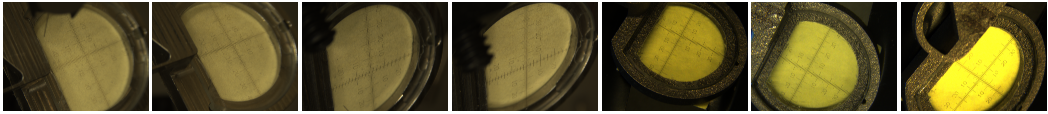

In [54]:
references = [p.relative_to(images).as_posix() for p in (images / "mapping/").iterdir()]
print(len(references), "mapping images")
plot_images([read_image(images / r) for r in references], dpi=25)

Then we extract features and match them across image pairs. Since we deal with few images, we simply match all pairs exhaustively. For larger scenes, we would use image retrieval, as demonstrated in the other notebooks.

In [55]:
extract_features.main(
    feature_conf, images, image_list=references, feature_path=features
)
pairs_from_exhaustive.main(sfm_pairs, image_list=references)
match_features.main(matcher_conf, sfm_pairs, features=features, matches=matches);

[2025/04/09 13:27:05 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 5000, 'name': 'disk'},
 'output': 'feats-disk',
 'preprocessing': {'grayscale': False, 'resize_max': 1600}}


  0%|          | 0/7 [00:00<?, ?it/s]

[2025/04/09 13:27:46 hloc INFO] Finished exporting features.
[2025/04/09 13:27:46 hloc INFO] Found 21 pairs.
[2025/04/09 13:27:46 hloc INFO] Matching local features with configuration:
{'model': {'features': 'disk', 'name': 'lightglue'},
 'output': 'matches-disk-lightglue'}


  0%|          | 0/21 [00:00<?, ?it/s]

[2025/04/09 13:30:35 hloc INFO] Finished exporting matches.


The we run incremental Structure-From-Motion and display the reconstructed 3D model.

In [56]:
fx, fy, cx, cy = 15400.0, 15400.0, 2000.0, 1500.0
opts = dict(
    camera_model='PINHOLE',
    camera_params=','.join(map(str, (fx, fy, cx, cy)))
)

mapper_options=dict(
    ba_refine_focal_length=False,
    ba_refine_extra_params=False
)

# ------------------------------------------------------------------
model = reconstruction.main(
    sfm_dir, images, sfm_pairs, features, matches, 
    image_list=references,
    image_options=opts,
    mapper_options = mapper_options
)
fig = viz_3d.init_figure()
viz_3d.plot_reconstruction(
    fig, model, color="rgba(255,0,0,0.5)", name="mapping", points_rgb=True
)
fig.show()

[2025/04/09 13:30:35 hloc INFO] Creating an empty database...
[2025/04/09 13:30:35 hloc INFO] Importing images into the database...
[2025/04/09 13:30:36 hloc INFO] Importing features into the database...


  0%|          | 0/7 [00:00<?, ?it/s]

[2025/04/09 13:30:36 hloc INFO] Importing matches into the database...


  0%|          | 0/21 [00:00<?, ?it/s]

[2025/04/09 13:30:36 hloc INFO] Performing geometric verification of the matches...
[2025/04/09 13:30:37 hloc INFO] Running 3D reconstruction...
[2025/04/09 13:30:44 hloc INFO] Reconstructed 2 model(s).
[2025/04/09 13:30:44 hloc INFO] Largest model is #1 with 7 images.
[2025/04/09 13:30:44 hloc INFO] Reconstruction statistics:
Reconstruction:
	num_reg_images = 7
	num_cameras = 7
	num_points3D = 1701
	num_observations = 4526
	mean_track_length = 2.66079
	mean_observations_per_image = 646.571
	mean_reprojection_error = 1.15621
	num_input_images = 7


We also visualize which keypoints were triangulated into the 3D model.

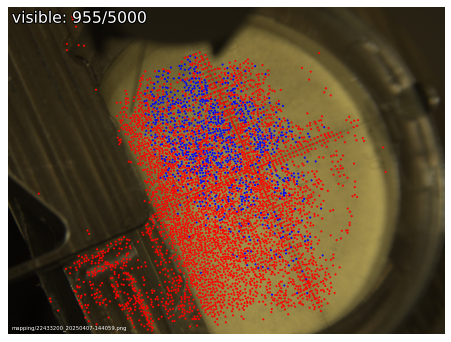

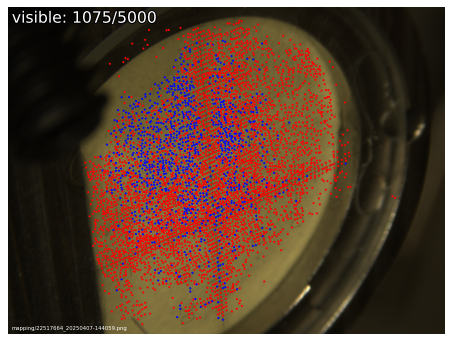

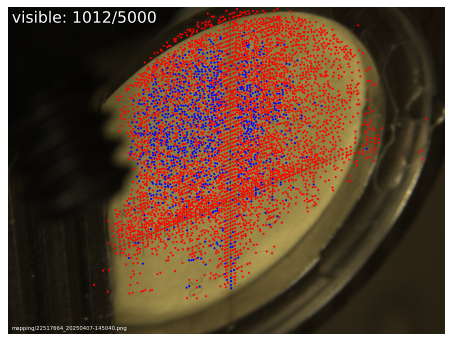

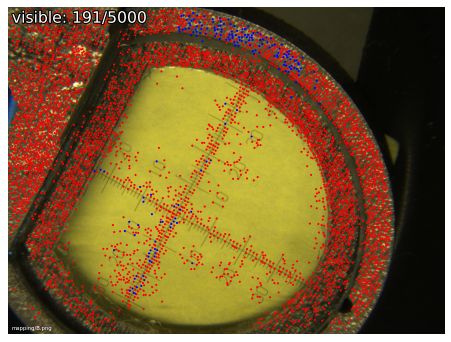

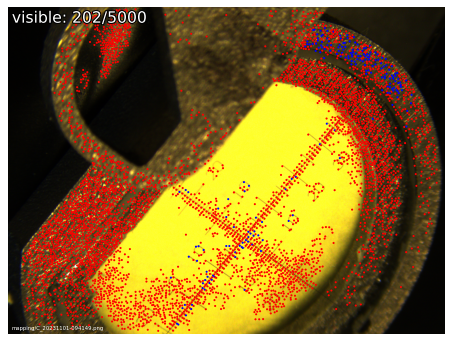

In [57]:
visualization.visualize_sfm_2d(model, images, color_by="visibility", n=5)

# Localization
Now that we have a 3D map of the scene, we can localize any image. To demonstrate this, we download [a night-time image from Wikimedia](https://commons.wikimedia.org/wiki/File:Paris_-_Basilique_du_Sacr%C3%A9_Coeur,_Montmartre_-_panoramio.jpg).

In [58]:
# List all files in the queries folder
images = Path(r"C:\Users\hanna.lee\Documents\00_Parallax\002_TestCode\000_ReticleImages")
query_folder = images / "queries"
for file in query_folder.glob("*"):
    print(file.name)


Microscope_1_20250403-094514.png
Microscope_3_20250403-094514.png


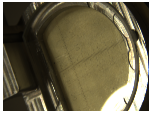

In [59]:
from hloc.utils.viz import plot_images
from pathlib import Path

# Define your base image folder
images = Path(r"C:\Users\hanna.lee\Documents\00_Parallax\002_TestCode\000_ReticleImages")

# Define your query image path (relative to `images`)
query = "queries/Microscope_3_20250403-094514.png"
#query = "queries/Microscope_1_20250403-094514.png"


# Plot it
plot_images([read_image(images / query)], dpi=25)


Again, we extract features for the query and match them exhaustively.

In [60]:
extract_features.main(
    feature_conf, images, image_list=[query], feature_path=features, overwrite=True
)
pairs_from_exhaustive.main(loc_pairs, image_list=[query], ref_list=references)
match_features.main(
    matcher_conf, loc_pairs, features=features, matches=matches, overwrite=True
);

[2025/04/09 13:30:50 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 5000, 'name': 'disk'},
 'output': 'feats-disk',
 'preprocessing': {'grayscale': False, 'resize_max': 1600}}


  0%|          | 0/1 [00:00<?, ?it/s]

[2025/04/09 13:30:56 hloc INFO] Finished exporting features.
[2025/04/09 13:30:56 hloc INFO] Found 7 pairs.
[2025/04/09 13:30:56 hloc INFO] Matching local features with configuration:
{'model': {'features': 'disk', 'name': 'lightglue'},
 'output': 'matches-disk-lightglue'}


  0%|          | 0/7 [00:00<?, ?it/s]

[2025/04/09 13:31:28 hloc INFO] Finished exporting matches.


We read the EXIF data of the query to infer a rough initial estimate of camera parameters like the focal length. Then we estimate the absolute camera pose using PnP+RANSAC and refine the camera parameters.

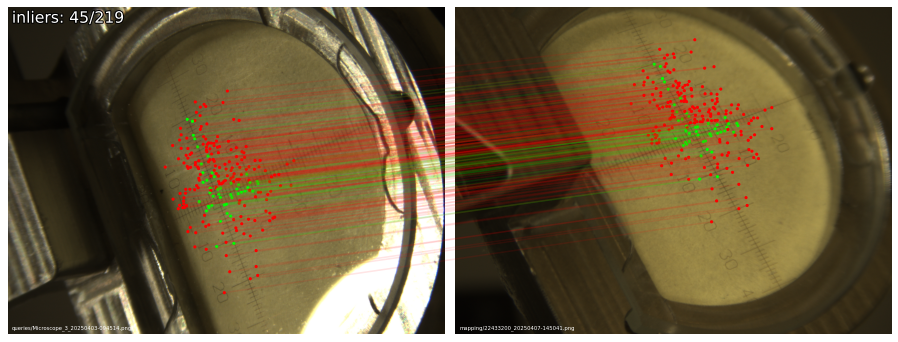

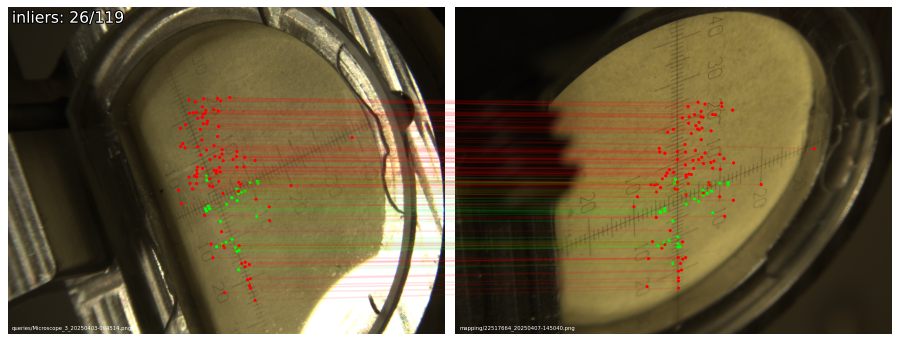

In [61]:
import pycolmap
from hloc.localize_sfm import QueryLocalizer, pose_from_cluster

camera = pycolmap.infer_camera_from_image(images / query)
ref_ids = [model.find_image_with_name(r).image_id for r in references]
conf = {
    "estimation": {"ransac": {"max_error": 12}},
    "refinement": {"refine_focal_length": True, "refine_extra_params": True},
}
localizer = QueryLocalizer(model, conf)
ret, log = pose_from_cluster(localizer, query, camera, ref_ids, features, matches)

#print(f'found {ret["num_inliers"]}/{len(ret["inliers"])} inlier correspondences.')
visualization.visualize_loc_from_log(images, query, log, model)

We visualize the correspondences between the query images a few mapping images. We can also visualize the estimated camera pose in the 3D map.

In [62]:
pose = pycolmap.Image(cam_from_world=ret["cam_from_world"])
viz_3d.plot_camera_colmap(
    fig, pose, camera, color="rgba(0,255,0,0.5)", name=query, fill=True
)
# visualize 2D-3D correspodences
inl_3d = np.array(
    [model.points3D[pid].xyz for pid in np.array(log["points3D_ids"])[ret["inliers"]]]
)
viz_3d.plot_points(fig, inl_3d, color="lime", ps=1, name=query)
fig.show()

In [63]:
model.write(outputs)
print(model)
for pt in model.points3D.values():
    print(pt.xyz, pt.color, pt.error)


Reconstruction(num_reg_images=7, num_cameras=7, num_points3D=1701, num_observations=4526)
[ 3.07844944 -0.39075622  8.88933268] [144 117  39] 0.03976760128516973
[3.22657394 0.38174351 9.56671885] [141 126  70] 1.3979785668578266
[3.2417342  0.77060467 9.77221293] [145 127  64] 0.3522549945996821
[ 3.01476484 -0.37754368  8.9074384 ] [157 126  44] 0.7660829293394572
[ 3.10189695 -0.37494779  8.89383122] [90 83 57] 1.6858310235124006
[2.97494894 0.14888967 9.46367491] [123 102  53] 1.2849906046405333
[ 3.00110945 -0.37413844  8.9022624 ] [103  99  62] 1.574897479622932
[ 3.05160096 -0.37275586  8.89713743] [90 73 54] 0.4740224172711275
[ 3.14639051 -0.37139578  8.89547579] [94 92 46] 1.4542460201654022
[3.06785792 0.60668061 9.68661389] [136 123  58] 0.7051328170707393
[ 3.24836962 -0.35763774  8.88624012] [111  88  44] 0.7488865374068359
[3.354817   0.57205886 9.66606458] [140 126  61] 1.904360975220278
[3.0399778  0.57446959 9.65841245] [142 124  64] 2.4233844815535157
[ 3.07883218 -0

In [64]:
from pathlib import Path

def write_points3D_to_ply(model, path):
    with open(path, 'w') as f:
        pts = list(model.points3D.values())
        f.write("ply\nformat ascii 1.0\nelement vertex {}\n".format(len(pts)))
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write("property uchar red\nproperty uchar green\nproperty uchar blue\nend_header\n")
        for pt in pts:
            x, y, z = pt.xyz
            r, g, b = pt.color
            f.write(f"{x:.6f} {y:.6f} {z:.6f} {r} {g} {b}\n")

# Usage
output_ply_path = Path("outputs/parallax-demo/sfm/points3D.ply")
write_points3D_to_ply(model, output_ply_path)
print(f"✅ Exported to {output_ply_path.resolve()}")


✅ Exported to C:\Users\hanna.lee\Documents\00_Parallax\000_Project\hloc\Hierarchical-Localization\outputs\parallax-demo\sfm\points3D.ply


Create the aligned model

In [65]:
import subprocess
import os
os.makedirs(sfm_aligned_dir, exist_ok=True)

colmap_cmd = [
    r"C:\Users\hanna.lee\Documents\00_Parallax\000_Project\colmap-x64-windows-cuda\COLMAP.bat", "model_aligner",
    "--input_path", str(sfm_dir),
    "--output_path", str(sfm_aligned_dir),
    "--ref_images_path", str(camera_centers),
    "--ref_is_gps", "0",
    "--alignment_type", "plane",
    "--alignment_max_error", "3.0"
]

result = subprocess.run(colmap_cmd, shell=True, capture_output=True, text=True)

print("STDOUT:\n", result.stdout)
print("STDERR:\n", result.stderr)
print("Return Code:", result.returncode)


STDOUT:
 
STDERR:
 I20250409 13:31:36.181315 21200 model.cc:135] 
Cartesian Alignment Coordinates extracted (MUST NOT BE GPS coords!).
I20250409 13:31:36.223930 21200 misc.cc:51] 
Aligning reconstruction to principal plane
------------------------------------------
I20250409 13:31:36.224321 21200 model.cc:425] => Alignment succeeded

Return Code: 0


In [ ]:
# Export to PLY of the aligned model
aligned_model = pycolmap.Reconstruction(sfm_aligned_dir,
    image_options=opts,
    mapper_options = mapper_options
)
print(len(aligned_model.images))  # Should be > 0
write_points3D_to_ply(aligned_model, sfm_aligned_dir / "points3D.ply")


5


In [67]:

fig = viz_3d.init_figure()
# Plot all 3D points
all_pts3D = np.array([pt.xyz for pt in aligned_model.points3D.values()])
viz_3d.plot_points(fig, all_pts3D, color="white", ps=1, name="all points")

fig.show()


In [68]:

# Set up camera intrinsics from the query image
camera = pycolmap.infer_camera_from_image(images / query)

# Map image names in references to IDs in the aligned model
ref_ids = [aligned_model.find_image_with_name(r).image_id for r in references]

# Localization config
conf = {
    "estimation": {"ransac": {"max_error": 12}},
    "refinement": {"refine_focal_length": True, "refine_extra_params": True},
}

# Run localization
localizer = QueryLocalizer(aligned_model, conf)
ret, log = pose_from_cluster(localizer, query, camera, ref_ids, features, matches)

# Visualize
fig = viz_3d.init_figure()

# Draw the full aligned model
viz_3d.plot_reconstruction(fig, aligned_model, name="aligned_model", color="rgba(255,0,0,0.4)", points_rgb=True)

# Draw the localized query pose
pose = pycolmap.Image(cam_from_world=ret["cam_from_world"])
viz_3d.plot_camera_colmap(fig, pose, camera, color="rgba(0,255,0,0.5)", name=query, fill=True)

# Draw inlier 3D points
inlier_ids = np.array(log["points3D_ids"])[ret["inliers"]]
inlier_xyz = np.array([aligned_model.points3D[pid].xyz for pid in inlier_ids])
viz_3d.plot_points(fig, inlier_xyz, color="lime", ps=1, name=f"{query}_inliers")

fig.show()

AttributeError: 'NoneType' object has no attribute 'image_id'